# Plot read length distribution

Here is the plotting of the read length distribution

In [60]:
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import glob


print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)
print("SciPy:", scipy.__version__)

# custom modules - Customized to BackupHaLab/
sys.path.append('/Volumes/BackupHaLab/condense-seq/postpro_scripts')
# import Helper_Py3
import graphics_edit as graphics
import load_file_edit as load_file
import Interval_dict_python3
import statis_edit as statis

Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
NumPy: 2.2.6
Matplotlib: 3.10.7
SciPy: 1.14.1


In [61]:
# matplotlib setting
%matplotlib inline
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"


In [62]:
### parameters
cell_org = {'H1':'human',
            'GM':'human',
            'E14':'mouse',
            'mCD8T:WT':'mouse',
            'mCD8T:DFMO':'mouse',
            'mCD8T:ODCKO':'mouse'}

cell_chrnames = {'H1':['chr%s' % (i) for i in range(1, 23)] + ['chrX', 'chrY'],
                 'GM':['chr%s' % (i) for i in range(1, 23)] + ['chrX'],
                 'E14':['chr%s' % (i) for i in range(1, 20)] + ['chrX', 'chrY'],
                 'mCD8T:WT':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'mCD8T:DFMO':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'mCD8T:ODCKO':['chr%s' % (i) for i in range(1, 20)] + ['chrX']}


In [63]:
agent_fullname = {'sp':'Spermine(4+)',
                  'spd':'Spermidine(3+)',
                  'CoH':'Cobalt Hexammine(3+)',
                  'PEG':'PEG 8000',
                  'HP1a':'HP1$\\alpha$',
                  'HP1bSUV':'HP1$\\beta$+tSUV',
                  'LKH':'Linker histone1',
                  'Ki67':'Ki67',
                  'FUS':'FUS',
                  'Mg':'Magnesium',
                  'Ca':'Calcium'}


In [64]:
### read rlen file
rlen_path = '/Volumes/BackupHaLab/Oct2025_run/analysis_v2/'
rlen_fnames = glob.glob(f"{rlen_path}/Exp1*_rlen.txt")
print(f"DEBUG: the file names are {rlen_fnames}.")
rlen_counts = [load_file.read_rlen_file (fname) for fname in rlen_fnames]

DEBUG: the file names are ['/Volumes/BackupHaLab/Oct2025_run/analysis_v2/Exp1-Samp11_S2_rlen.txt', '/Volumes/BackupHaLab/Oct2025_run/analysis_v2/Exp1-Samp15_S3_rlen.txt', '/Volumes/BackupHaLab/Oct2025_run/analysis_v2/Exp1-Samp1_S1_rlen.txt'].


In [65]:
### read titration file
titr_path = '/Volumes/BackupHaLab/Oct2025_run/analysis_v2/titration_files/'
titr_fname = 'Exp1-titration.tsv'
tnum_conc, tnum_frac = load_file.read_titration (titr_path + titr_fname)

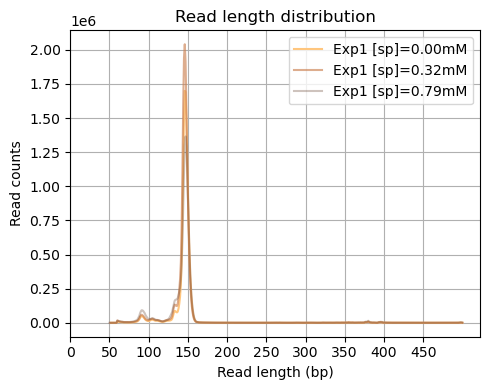

<Axes: title={'center': 'Read length distribution'}, xlabel='Read length (bp)', ylabel='Read counts'>

In [66]:
### plot rlen distribution [Extended Data Fig.2c]
labels = ['Exp1 [sp]=%.2fmM' % (tnum_conc[i]) for i in range(len(rlen_fnames))]
colors = np.linspace(0.01, 0.7, num=len(rlen_counts))
alphas = np.linspace(0.3, 1, num=len(rlen_counts))[::-1]
cmap = mpl.colormaps["copper_r"]

graphics.plot_rlen_dist (rlen_counts,
                         colors=[cmap(color) for color in colors],
                         alphas=alphas,
                         labels=labels,
                         fig_width=5,
                         fig_height=4,
                         save_path=rlen_path,
                         save=False,
                         note='E14_NCP_sp')
